In [ ]:
from pathlib import Path

BASE = Path().resolve().parent  # TRM_project/
OUT = BASE / "processed_data"
GRN = BASE / "GRN_SCENIC"
FIG = BASE / "figures_results"


In [1]:
import sys, numpy as np, pandas as pd
print(sys.version)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
numpy: 1.23.5
pandas: 1.5.3


In [2]:
import pandas as pd

auc = pd.read_csv(str(GRN / "trm_auc.csv"), index_col=0)

auc.head()


,CHD1(+),CXXC1(+),DBP(+),ELF1(+),ELK3(+),EOMES(+),ETS1(+),FLI1(+),FOSB(+),FOXK1(+),...,RUNX3(+),SP2(+),SP3(+),TCF7(+),XRCC4(+),ZBTB49(+),ZNF182(+),ZNF195(+),ZNF528(+),ZNF740(+)
Cell,,,,,,,,,,,,,,,,,,,,,
AACTTTCCAAGCCGCT-1-BCH01-L1,0.000000,0.040351,0.328333,0.014286,0.031950,0.039020,0.024794,0.032421,0.057222,0.000000,...,0.000000,0.032099,0.000000,0.0,0.006795,0.040833,0.238333,0.098333,0.000000,0.114333
AAGGAGCCAAGACACG-1-BCH01-L1,0.000000,0.000000,0.224167,0.011575,0.023774,0.042549,0.050487,0.047088,0.063611,0.000000,...,0.000000,0.081481,0.000000,0.0,0.052372,0.042917,0.000000,0.000000,0.114444,0.000000
AAGGCAGCAATCCAAC-1-BCH01-L1,0.000000,0.040702,0.000000,0.016215,0.046457,0.019412,0.045993,0.039298,0.046944,0.000000,...,0.000000,0.000000,0.000000,0.0,0.022821,0.161667,0.210000,0.000000,0.000000,0.103333
AAGTCTGTCCACGTTC-1-BCH01-L1,0.045625,0.000000,0.091667,0.019121,0.023522,0.020588,0.029588,0.013754,0.510000,0.154444,...,0.029111,0.052099,0.000000,0.0,0.006218,0.082083,0.000000,0.000000,0.228889,0.072333
ACATGGTTCTCTAAGG-1-BCH01-L1,0.000000,0.097193,0.000000,0.012381,0.037610,0.072353,0.009288,0.007930,0.031389,0.000000,...,0.059778,0.032593,0.131905,0.0,0.025321,0.100417,0.000000,0.117500,0.000000,0.087000


In [3]:
auc.mean().sort_values(ascending=False).head(20)


ZBTB49(+)    0.091334
ZNF528(+)    0.081473
ZNF740(+)    0.068056
POU2F1(+)    0.061130
FOSB(+)      0.057484
EOMES(+)     0.055098
RUNX2(+)     0.050790
ZNF195(+)    0.047828
SP2(+)       0.046805
FOXP4(+)     0.045734
REL(+)       0.045283
KLF2(+)      0.043639
ELK3(+)      0.043182
ETS1(+)      0.041673
RUNX3(+)     0.040367
FLI1(+)      0.040080
CHD1(+)      0.038518
RORA(+)      0.037881
NFATC2(+)    0.037762
XRCC4(+)     0.034013
dtype: float64

In [4]:
trm_meta = pd.read_csv(str(OUT / "trm_meta.tsv"), sep="\t", index_col=0)

auc_high = auc.loc[trm_meta["IL22_high"] == 1]

auc_high.mean().sort_values(ascending=False).head(20)


ZBTB49(+)    0.107315
ZNF528(+)    0.105926
POU2F1(+)    0.098422
FOSB(+)      0.092099
RORA(+)      0.068395
KLF2(+)      0.062466
RUNX2(+)     0.061867
REL(+)       0.056701
FOXP4(+)     0.056296
ZNF740(+)    0.055704
ELK3(+)      0.055253
SP3(+)       0.053386
SP2(+)       0.051276
EOMES(+)     0.049717
ZNF195(+)    0.048333
NFATC2(+)    0.042774
KDM5B(+)     0.041266
CHD1(+)      0.040833
DBP(+)       0.040648
ETS1(+)      0.037586
dtype: float64

In [5]:
# IL22 low cells
auc_low = auc.loc[trm_meta["IL22_high"] == 0]

# 差值
delta = auc_high.mean() - auc_low.mean()

delta.sort_values(ascending=False).head(20)


POU2F1(+)    0.041487
FOSB(+)      0.038508
RORA(+)      0.033947
SP3(+)       0.032928
ZNF528(+)    0.027204
KLF2(+)      0.020945
ZBTB49(+)    0.017778
KDM5B(+)     0.015688
ELK3(+)      0.013428
REL(+)       0.012702
DBP(+)       0.012481
RUNX2(+)     0.012323
FOXP4(+)     0.011750
NFATC2(+)    0.005576
SP2(+)       0.004973
CXXC1(+)     0.004231
ELF1(+)      0.003664
CHD1(+)      0.002576
XRCC4(+)     0.002057
ZNF195(+)    0.000562
dtype: float64

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

top_tfs = delta.sort_values(ascending=False).head(15).index

plt.figure(figsize=(8,6))
sns.heatmap(
    auc.loc[:, top_tfs].groupby(trm_meta["IL22_high"]).mean(),
    cmap="viridis"
)
plt.title("Top differential regulons")
plt.show()


ModuleNotFoundError: No module named 'seaborn'

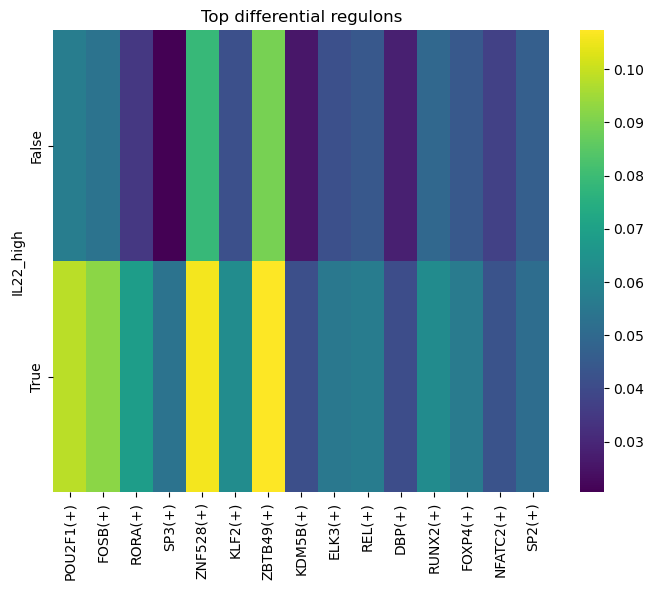

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

top_tfs = delta.sort_values(ascending=False).head(15).index

plt.figure(figsize=(8,6))
sns.heatmap(
    auc.loc[:, top_tfs].groupby(trm_meta["IL22_high"]).mean(),
    cmap="viridis"
)
plt.title("Top differential regulons")
plt.show()


In [8]:
import scanpy as sc

trm.obsm["X_regulon"] = auc.loc[trm.obs_names]
sc.pp.scale(trm, obsm="X_regulon")
sc.tl.pca(trm)
sc.tl.umap(trm)
sc.pl.umap(trm, color=["IL22", "POU2F1(+)", "RORA(+)"])


ModuleNotFoundError: No module named 'scanpy'

In [9]:
delta.sort_values(ascending=False).head(30)


POU2F1(+)    0.041487
FOSB(+)      0.038508
RORA(+)      0.033947
SP3(+)       0.032928
ZNF528(+)    0.027204
KLF2(+)      0.020945
ZBTB49(+)    0.017778
KDM5B(+)     0.015688
ELK3(+)      0.013428
REL(+)       0.012702
DBP(+)       0.012481
RUNX2(+)     0.012323
FOXP4(+)     0.011750
NFATC2(+)    0.005576
SP2(+)       0.004973
CXXC1(+)     0.004231
ELF1(+)      0.003664
CHD1(+)      0.002576
XRCC4(+)     0.002057
ZNF195(+)    0.000562
FLI1(+)     -0.004505
ETS1(+)     -0.004547
RFX2(+)     -0.004946
EOMES(+)    -0.005987
KDM5A(+)    -0.008133
RBBP5(+)    -0.012886
ZNF740(+)   -0.013742
IKZF3(+)    -0.014220
RUNX3(+)    -0.019527
FOXK1(+)    -0.022431
dtype: float64

In [10]:
delta.sort_values().head(20)


ZNF182(+)   -0.032146
TCF7(+)     -0.030583
FOXK1(+)    -0.022431
RUNX3(+)    -0.019527
IKZF3(+)    -0.014220
ZNF740(+)   -0.013742
RBBP5(+)    -0.012886
KDM5A(+)    -0.008133
EOMES(+)    -0.005987
RFX2(+)     -0.004946
ETS1(+)     -0.004547
FLI1(+)     -0.004505
ZNF195(+)    0.000562
XRCC4(+)     0.002057
CHD1(+)      0.002576
ELF1(+)      0.003664
CXXC1(+)     0.004231
SP2(+)       0.004973
NFATC2(+)    0.005576
FOXP4(+)     0.011750
dtype: float64

In [11]:
import scipy.stats as stats

pvals = []
for tf in auc.columns:
    stat, p = stats.ttest_ind(
        auc_high[tf],
        auc_low[tf],
        equal_var=False
    )
    pvals.append(p)

pvals = pd.Series(pvals, index=auc.columns)


In [12]:
result = pd.DataFrame({
    "delta": delta,
    "pval": pvals
}).sort_values("delta", ascending=False)

result.head(20)


,delta,pval
POU2F1(+),0.041487,0.039562
FOSB(+),0.038508,0.388388
RORA(+),0.033947,0.086781
SP3(+),0.032928,0.209607
ZNF528(+),0.027204,0.175408
KLF2(+),0.020945,0.551296
ZBTB49(+),0.017778,0.255185
KDM5B(+),0.015688,0.547085
ELK3(+),0.013428,0.411212
REL(+),0.012702,0.469442


In [13]:
regulons = pd.read_csv(str(GRN / "trm_regulons.csv"))
regulon_size = regulons.groupby("Regulon").size()

result["size"] = regulon_size
result.sort_values("delta", ascending=False).head(20)


KeyError: 'Regulon'

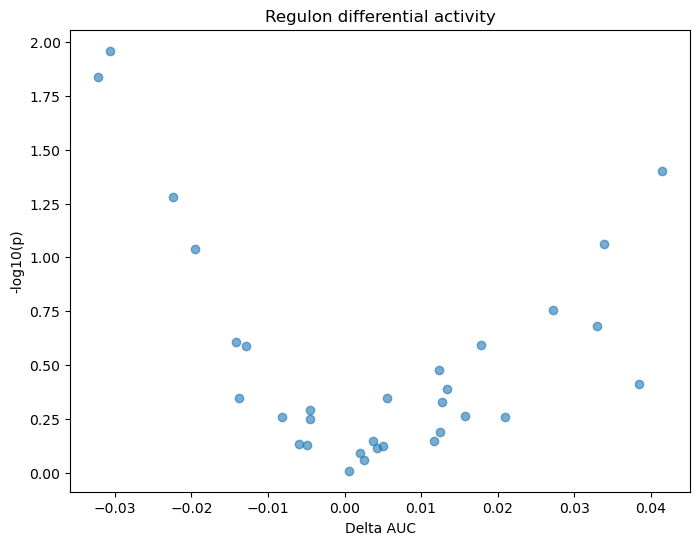

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(result["delta"], -np.log10(result["pval"]), alpha=0.6)
plt.xlabel("Delta AUC")
plt.ylabel("-log10(p)")
plt.title("Regulon differential activity")
plt.show()


In [15]:
trm_expr.loc[:, delta.head(20).index]


NameError: name 'trm_expr' is not defined

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# 1) AUC
auc = pd.read_csv(str(GRN / "trm_auc.csv"), index_col=0)

# 2) metadata（你已經有 trm_meta.tsv）
trm_meta = pd.read_csv(str(OUT / "trm_meta.tsv"), sep="\t", index_col=0)

# 3) regulons（ctx output）
reg = pd.read_csv(str(GRN / "trm_regulons.csv"))

print("AUC shape:", auc.shape)
print("META shape:", trm_meta.shape)
print("REG columns:", list(reg.columns))
reg.head()


AUC shape: (89, 32)
META shape: (89, 74)
REG columns: ['Unnamed: 0', 'Unnamed: 1', 'Enrichment', 'Enrichment.1', 'Enrichment.2', 'Enrichment.3', 'Enrichment.4', 'Enrichment.5', 'Enrichment.6', 'Enrichment.7']


,Unnamed: 0,Unnamed: 1,Enrichment,Enrichment.1,Enrichment.2,Enrichment.3,Enrichment.4,Enrichment.5,Enrichment.6,Enrichment.7
0,NaN,NaN,AUC,NES,MotifSimilarityQvalue,OrthologousIdentity,Annotation,Context,TargetGenes,RankAtMax
1,TF,MotifID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHD1,transfac_pro__M04787,0.07134795288414196,3.1409838205780156,7.4e-05,1.0,motif similar to dbcorrdb__CHD1__ENCSR000EFC_1...,"frozenset({'activating', 'hg38__refseq-r80__10...","[('XRCC1', 4.4273635940705685), ('BIRC3', 0.90...",1634
3,ELF1,predrem__nrMotif2167,0.04944969513888118,3.0883645615729933,0.000785,1.0,gene is annotated for similar motif dbcorrdb__...,"frozenset({'activating', 'hg38__refseq-r80__10...","[('TBC1D23', 7.939686147352721), ('DHX40', 0.2...",999
4,ELF1,dbcorrdb__RBBP5__ENCSR000AQC_1__m5,0.05520448092165421,3.928609057991084,0.000625,1.0,motif similar to dbcorrdb__ELF1__ENCSR000BPT_1...,"frozenset({'activating', 'hg38__refseq-r80__10...","[('EPSTI1', 0.8879742709729483), ('SOCS1', 3.1...",905


In [17]:
# 找出 regulon 名稱欄位（通常叫 'regulon' 或 'Regulon' 或 'TF'）
# 我們用「包含 regulon 字樣」或「包含 TF 字樣」的欄位優先
cand_cols = [c for c in reg.columns if "regul" in c.lower()]
if len(cand_cols) == 0:
    cand_cols = [c for c in reg.columns if c.lower() in ["tf", "factor", "name"]]
reg_name_col = cand_cols[0] if len(cand_cols) else reg.columns[0]

# 找出 target gene 欄位（通常叫 'TargetGenes'/'targets'/'gene'）
cand_tcols = [c for c in reg.columns if "target" in c.lower() or "gene" in c.lower()]
tcol = cand_tcols[0] if len(cand_tcols) else None

print("Using regulon name col:", reg_name_col)
print("Using target col:", tcol)

# 計算 regulon size
if tcol is not None:
    # 目標基因可能是一個以逗號/空白分隔的字串；我們先轉成長表
    def count_targets(x):
        if pd.isna(x): return 0
        s = str(x)
        # 常見分隔符：逗號、空白、分號
        parts = [p for p in re.split(r"[,\s;]+", s) if p]
        return len(parts)
    import re
    reg["_size"] = reg[tcol].apply(count_targets)
    regulon_size = reg.groupby(reg_name_col)["_size"].max()  # 同 regulon 取最大（避免重複列）
else:
    # 如果沒有 targets 欄，就用「每個 regulon 出現幾列」當 size proxy
    regulon_size = reg.groupby(reg_name_col).size()

regulon_size.sort_values(ascending=False).head(10)


Using regulon name col: Unnamed: 0
Using target col: None


Unnamed: 0
REL       116
XRCC4     103
ELK3       89
EOMES      87
ELF1       57
SP2        40
POU2F1     34
ETS1       32
FLI1       28
RBBP5      10
dtype: int64

In [18]:
# 讓 meta index 與 auc index 對齊
common = auc.index.intersection(trm_meta.index)
auc2 = auc.loc[common]
meta2 = trm_meta.loc[common]

# IL22_high 欄位名確認
print("META columns:", list(meta2.columns))

# 你目前用的是 trm_meta["IL22_high"]，我們沿用
il22 = meta2["IL22_high"]

# 轉成布林
if il22.dtype != bool:
    il22 = il22.astype(int) == 1

auc_high = auc2.loc[il22]
auc_low  = auc2.loc[~il22]

auc_high.shape, auc_low.shape


META columns: ['10x_cell_calling', 'G2M_score', 'S_score', 'barcode_rank', 'chemistry_10x', 'disease_status', 'empty_drops_FDR', 'ind_id', 'lesional', 'log10_n_genes', 'log10_n_umis', 'mito_cutoff_', 'mt_frac', 'n_counts', 'n_genes', 'n_umis', 'neg_log10_empty_drops_FDR', 'phase', 'predicted_cell_types', 'sample_name', 'scrublet', 'scrublet_score', 'sex', 'disease_lesional', 'batch', 'leiden', 'Cell type', 'Cell type granular', 'ind_sample', 'channel', 'barcode', 'subject_id', 'global_disease_assessment', 'ad_family_history', 'sex_clinical', 'ethnicity_race', 'smoking', 'asthma', 'other_condition', 'systemic_corticosteroids', 'topical_corticosteroids', 'dupilumab', 'dupilumab_indication', 'dupilumab_other_indication', 'location', 'side', 'Disease score (MADAD Immune)', 'Disease score (MADAD Full)', 'Disease score (MADAD Union)', 'Cell type new cornified', 'ind_disease_lesional', 'Cell states with PathT', 'Cell type granular v2', 'Cell states with PathT v2', 'Compartment', 'condition', 

((9, 32), (80, 32))

In [19]:
# delta AUC
delta = auc_high.mean() - auc_low.mean()

# 非參數檢定（小樣本更穩）：Mann-Whitney U
pvals = {}
for r in auc2.columns:
    try:
        pvals[r] = mannwhitneyu(auc_high[r], auc_low[r], alternative="two-sided").pvalue
    except Exception:
        pvals[r] = np.nan
pvals = pd.Series(pvals)

# 對應 regulon size（AUC 欄名像 "RORA(+)"；regulon 表裡可能是 "RORA"）
def normalize_reg_name(x):
    x = str(x)
    x = x.replace("(+)", "").replace("(-)", "")
    return x

size_map = regulon_size.copy()
size_map.index = size_map.index.map(normalize_reg_name)

sizes = pd.Series({r: size_map.get(normalize_reg_name(r), np.nan) for r in auc2.columns})

# locking score：delta * (-log10 p) * size_weight
# size_weight：避免 tiny regulon 噪音（用 log1p(size) 標準化）
size_weight = np.log1p(sizes)
size_weight = size_weight / np.nanmax(size_weight)

locking = delta * (-np.log10(pvals)) * size_weight

result = pd.DataFrame({
    "delta_auc": delta,
    "pval": pvals,
    "neglog10_p": -np.log10(pvals),
    "regulon_size": sizes,
    "size_weight": size_weight,
    "locking_score": locking
}).sort_values("locking_score", ascending=False)

result.head(25)


,delta_auc,pval,neglog10_p,regulon_size,size_weight,locking_score
POU2F1(+),0.041487,0.002912,2.535735,34,0.746581,0.078541
RORA(+),0.033947,0.006370,2.195894,5,0.376248,0.028047
ELK3(+),0.013428,0.102468,0.989414,89,0.944907,0.012554
SP3(+),0.032928,0.037969,1.420575,1,0.145553,0.006808
REL(+),0.012702,0.304214,0.516820,116,1.000000,0.006565
ZBTB49(+),0.017778,0.054960,1.259953,3,0.291105,0.006521
ZNF528(+),0.027204,0.132992,0.876175,2,0.230696,0.005499
NFATC2(+),0.005576,0.024134,1.617375,9,0.483516,0.004361
RUNX2(+),0.012323,0.069752,1.156441,3,0.291105,0.004149
FOSB(+),0.038508,0.586152,0.231990,5,0.376248,0.003361


In [20]:
result.to_csv(str(FIG / "locking_tf_rank.csv"))
print("Wrote: locking_tf_rank.csv")


Wrote: locking_tf_rank.csv


In [21]:
# 嚴格 memory filter
memory_candidates = result[
    (result["delta_auc"] > 0) &
    (result["pval"] < 0.05) &
    (result["regulon_size"] > 20)
].copy()

# 依 locking_score 重新排序
memory_candidates = memory_candidates.sort_values(
    "locking_score", ascending=False
)

memory_candidates.head(20)


,delta_auc,pval,neglog10_p,regulon_size,size_weight,locking_score
POU2F1(+),0.041487,0.002912,2.535735,34,0.746581,0.078541


In [22]:
memory_candidates = result[
    (result["delta_auc"] > 0.01) &
    (result["pval"] < 0.05) &
    (result["regulon_size"] > 20)
].copy()

memory_candidates = memory_candidates.sort_values(
    "locking_score", ascending=False
)

memory_candidates


,delta_auc,pval,neglog10_p,regulon_size,size_weight,locking_score
POU2F1(+),0.041487,0.002912,2.535735,34,0.746581,0.078541


In [23]:
memory_negative = result[
    (result["delta_auc"] < 0) &
    (result["pval"] < 0.05) &
    (result["regulon_size"] > 20)
].copy()

memory_negative = memory_negative.sort_values(
    "locking_score", ascending=True
)

memory_negative.head(20)


,delta_auc,pval,neglog10_p,regulon_size,size_weight,locking_score


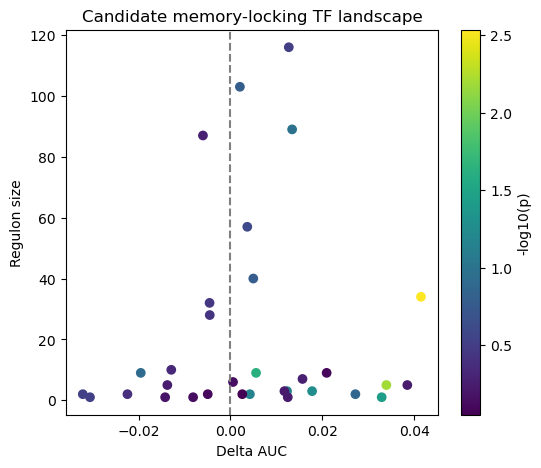

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(result["delta_auc"], result["regulon_size"],
            c=result["neglog10_p"], cmap="viridis")

plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("Delta AUC")
plt.ylabel("Regulon size")
plt.title("Candidate memory-locking TF landscape")
plt.colorbar(label="-log10(p)")
plt.show()


In [25]:
(result["delta_auc"] > 0.01)


POU2F1(+)     True
RORA(+)       True
ELK3(+)       True
SP3(+)        True
REL(+)        True
ZBTB49(+)     True
ZNF528(+)     True
NFATC2(+)    False
RUNX2(+)      True
FOSB(+)       True
SP2(+)       False
ELF1(+)      False
KDM5B(+)      True
XRCC4(+)     False
CXXC1(+)     False
KLF2(+)       True
FOXP4(+)      True
DBP(+)        True
ZNF195(+)    False
CHD1(+)      False
RFX2(+)      False
KDM5A(+)     False
IKZF3(+)     False
ZNF740(+)    False
FLI1(+)      False
ETS1(+)      False
EOMES(+)     False
FOXK1(+)     False
RBBP5(+)     False
TCF7(+)      False
ZNF182(+)    False
RUNX3(+)     False
Name: delta_auc, dtype: bool